<a href="https://colab.research.google.com/github/sayaleedamle/BDM_proj/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# Define transforms for the training and test sets
# CIFAR-10 images are 32x32 RGB images

# Training transforms with data augmentation
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),           # Randomly flip images horizontally
    transforms.RandomCrop(32, padding=4),        # Random crop with padding
    transforms.ToTensor(),                       # Convert PIL image to tensor [0, 1]
    transforms.Normalize(                        # Normalize to [-1, 1] range
        mean=(0.4914, 0.4822, 0.4465),          # CIFAR-10 channel means
        std=(0.2470, 0.2435, 0.2616)            # CIFAR-10 channel stds
    )
])

# Test transforms (no augmentation)
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    )
])

In [ ]:
# Download and load CIFAR-10 dataset
train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=test_transform
)

# Class names for CIFAR-10
classes = ('airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

100%|██████████| 170M/170M [00:06<00:00, 26.7MB/s]


Training samples: 50000
Test samples: 10000


In [ ]:
from torch.utils.data import DataLoader, random_split

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

print(f"Train samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")


Train samples: 40000
Validation samples: 10000


In [ ]:
# Create DataLoaders
# DataLoader handles batching, shuffling, and parallel data loading

BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,           # Shuffle training data each epoch
    num_workers=2,          # Parallel data loading
    pin_memory=True         # Faster data transfer to GPU
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,          # No need to shuffle test data
    num_workers=2,
    pin_memory=True
)

val_loader= DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,            # Shuffle training data each epoch
    num_workers=2,          # Parallel data loading
    pin_memory=True)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of test batches: {len(test_loader)}")
print(f"Number of val batches: {len(val_loader)}")

Number of training batches: 313
Number of test batches: 79
Number of val batches: 79


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BaselineCNN(nn.Module):
    def __init__(self):
        super(BaselineCNN, self).__init__()

        # Block 1: Input 3x32x32 -> Conv(32 filters) -> MaxPool
        # Padding=1 with a 3x3 kernel keeps spatial dimensions the same before pooling
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Block 2: Conv(64 filters) -> MaxPool
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Block 3: Conv(64 filters)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1)

        # Fully Connected Layer
        # After two MaxPools (32->16->8), the spatial map is 8x8.
        # Flattened size = 64 filters * 8 * 8 = 4096
        self.fc1 = nn.Linear(64 * 8 * 8, 64)

        # Output Layer (10 classes for CIFAR-10)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        # Block 1
        x = F.relu(self.conv1(x))
        x = self.pool1(x)

        # Block 2
        x = F.relu(self.conv2(x))
        x = self.pool2(x)

        # Block 3
        x = F.relu(self.conv3(x))

        # Flatten
        x = x.view(-1, 64 * 8 * 8)

        # Fully Connected
        x = F.relu(self.fc1(x))

        # Output
        x = self.fc2(x)
        return x

# Initialize the model
model = BaselineCNN().to(device)
print(model)

BaselineCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=4096, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)


In [ ]:
import torch.optim as optim


criterion = nn.CrossEntropyLoss().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)



Epoch 1/15 | Train Acc: 75.73% | Val Acc: 73.02%


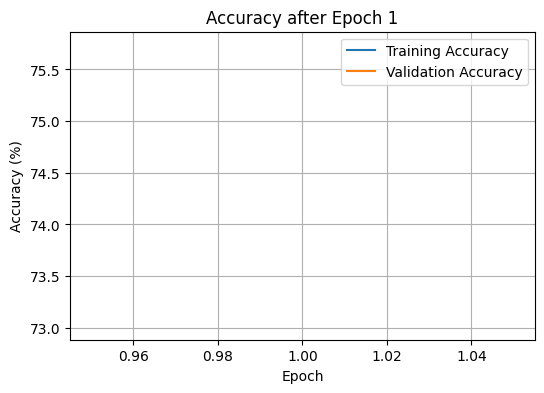

Epoch 2/15 | Train Acc: 76.21% | Val Acc: 73.79%


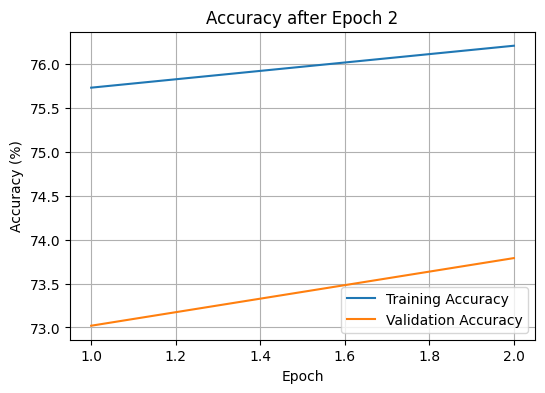

Epoch 3/15 | Train Acc: 76.37% | Val Acc: 74.83%


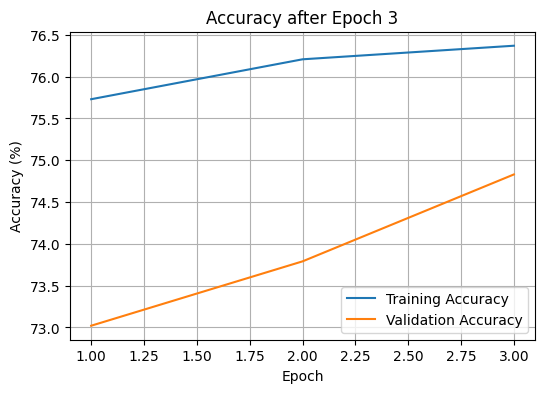

Epoch 4/15 | Train Acc: 76.81% | Val Acc: 74.54%


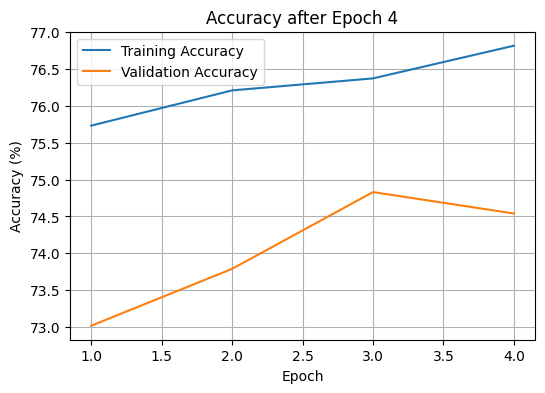

Epoch 5/15 | Train Acc: 77.61% | Val Acc: 75.60%


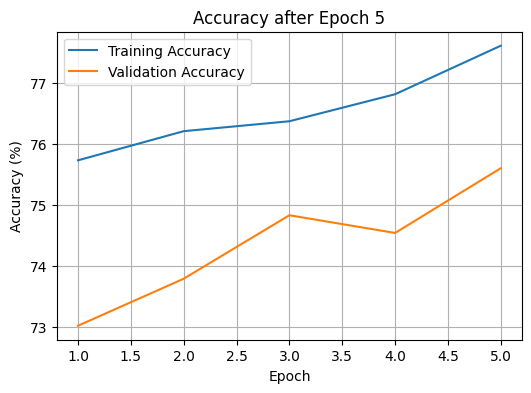

Epoch 6/15 | Train Acc: 77.79% | Val Acc: 76.31%


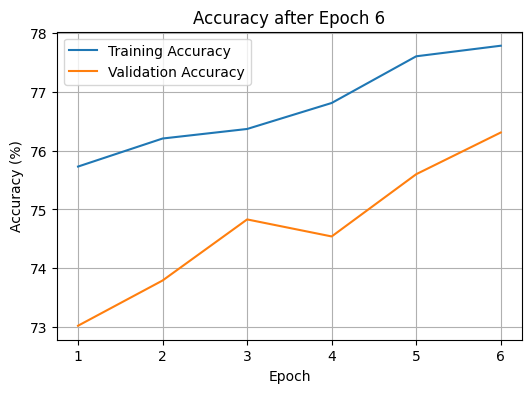

Epoch 7/15 | Train Acc: 78.08% | Val Acc: 75.91%


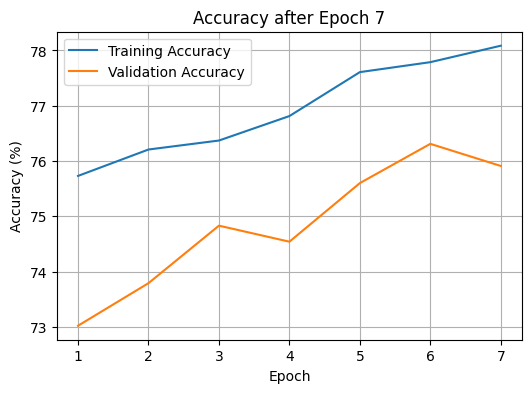

Epoch 8/15 | Train Acc: 78.06% | Val Acc: 76.88%


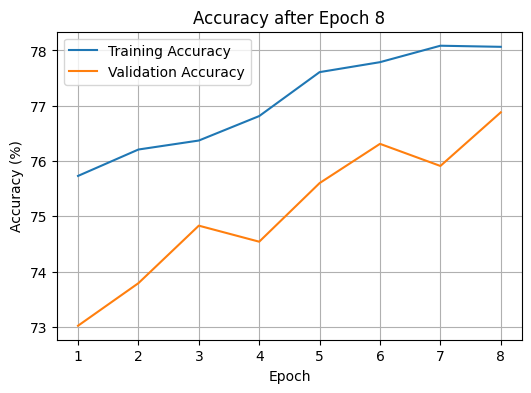

Epoch 9/15 | Train Acc: 78.95% | Val Acc: 75.30%


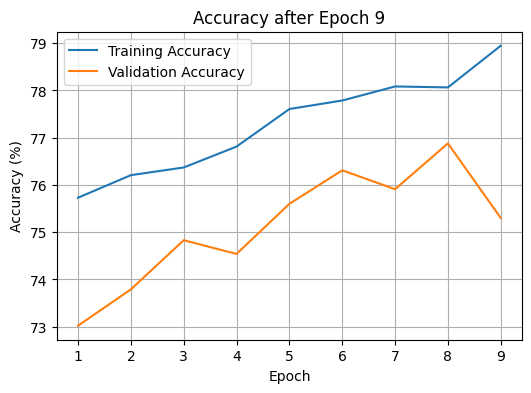

Epoch 10/15 | Train Acc: 78.74% | Val Acc: 76.88%


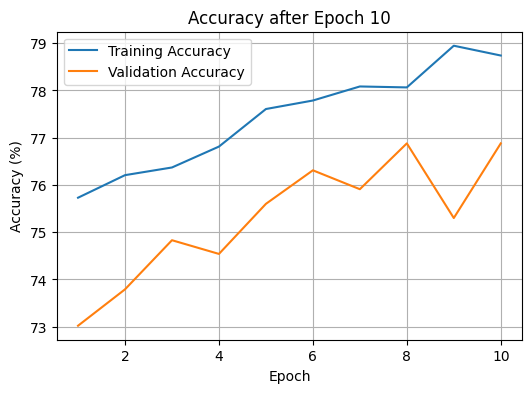

Epoch 11/15 | Train Acc: 79.22% | Val Acc: 77.17%


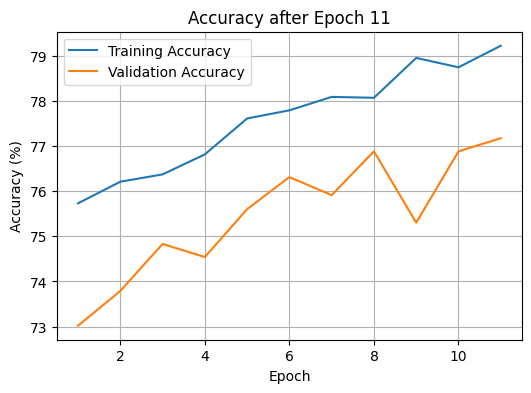

Epoch 12/15 | Train Acc: 79.87% | Val Acc: 76.70%


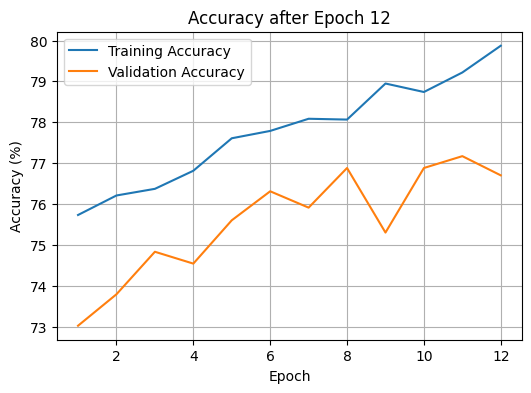

Epoch 13/15 | Train Acc: 79.71% | Val Acc: 76.90%


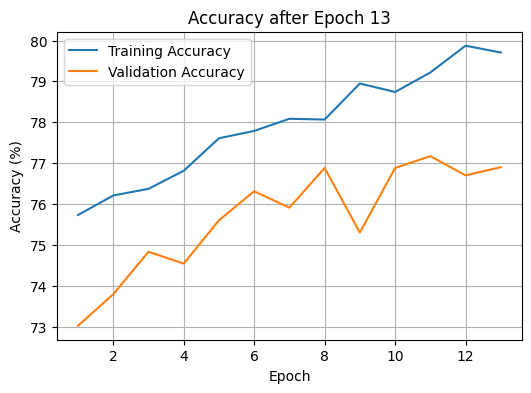

Epoch 14/15 | Train Acc: 80.33% | Val Acc: 77.54%


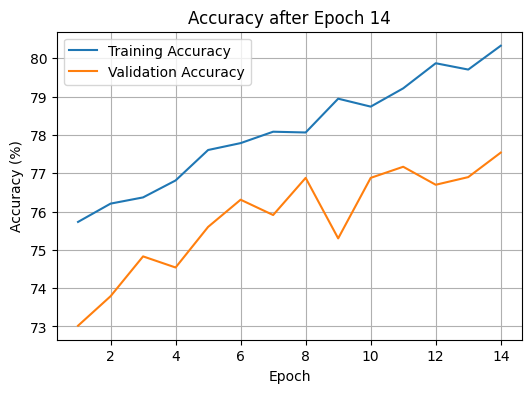

Epoch 15/15 | Train Acc: 80.23% | Val Acc: 77.17%


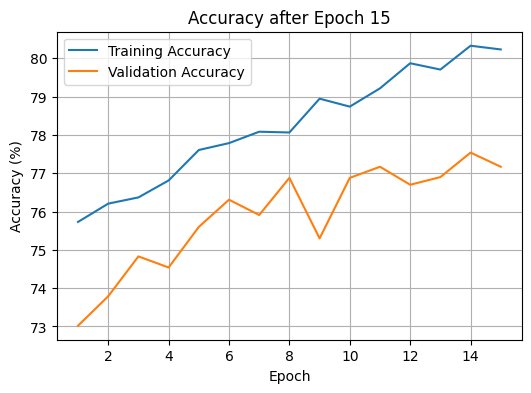

In [ ]:
import matplotlib.pyplot as plt

train_acc_list = []
val_acc_list = []

epochs = 15

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_acc = 100 * correct_train / total_train
    train_acc_list.append(train_acc)

    # ---- Validation / Test Accuracy ----
    model.eval()
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:   # or test_loader
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_acc = 100 * correct_val / total_val
    val_acc_list.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

    plt.figure(figsize=(6,4))
    plt.plot(range(1, epoch+2), train_acc_list, label="Training Accuracy")
    plt.plot(range(1, epoch+2), val_acc_list, label="Validation Accuracy")

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title(f"Accuracy after Epoch {epoch+1}")
    plt.legend()
    plt.grid(True)
    plt.show()


In [ ]:
from torchsummary import summary
summary(model, input_size=(3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
         MaxPool2d-2           [-1, 32, 16, 16]               0
            Conv2d-3           [-1, 64, 16, 16]          18,496
         MaxPool2d-4             [-1, 64, 8, 8]               0
            Conv2d-5             [-1, 64, 8, 8]          36,928
            Linear-6                   [-1, 64]         262,208
            Linear-7                   [-1, 10]             650
Total params: 319,178
Trainable params: 319,178
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 0.50
Params size (MB): 1.22
Estimated Total Size (MB): 1.73
----------------------------------------------------------------


#Test Loop

In [ ]:
model.eval()

correct_test = 0
total_test = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = 100 * correct_test / total_test
print(f"Test Accuracy: {test_acc:.2f}%")


Test Accuracy: 79.02%


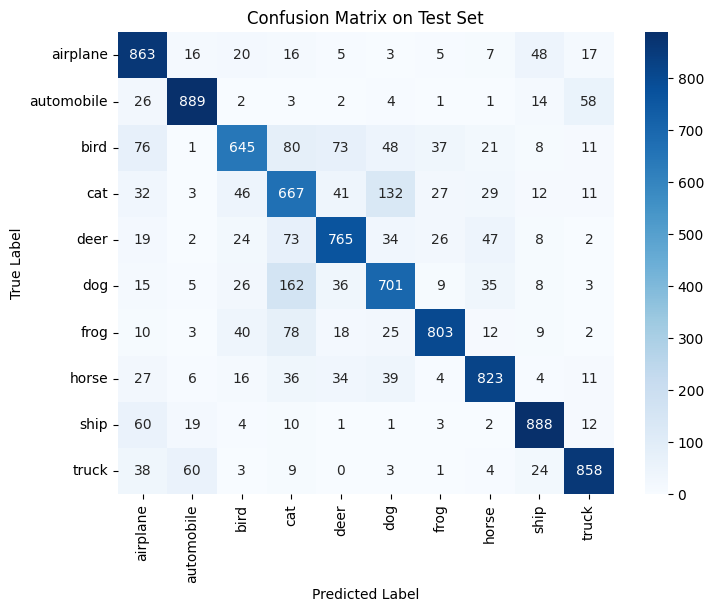

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes,
            yticklabels=classes)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix on Test Set")
plt.show()


In [ ]:
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

i, j = np.unravel_index(np.argmax(cm_no_diag), cm_no_diag.shape)
print(f"Most confused classes: {classes[i]} → {classes[j]}")


Most confused classes: dog → cat


Q. Provide a plausible explanation for these errors based on visual similarity.

These errors are likely due to the strong visual resemblance between these categories. For example, cats and dogs share similar body structures, fur textures, and backgrounds in many CIFAR-10 images.
Additionally, CIFAR-10 images are low resolution (32×32 pixels), which makes it difficult for the model to capture fine-grained details such as facial features or subtle shape differences

#Part B

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class EnhancedCNN(nn.Module):
    def __init__(self):
        super(EnhancedCNN, self).__init__()

        # Block 1
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)

        # Block 2
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)

        # Block 3
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)

        # 1x1 Convolution for classification
        self.conv1x1 = nn.Conv2d(128, 10, kernel_size=1)

        # Pooling
        self.pool = nn.MaxPool2d(2,2)
        self.gap  = nn.AdaptiveAvgPool2d((1,1))  # Global Average Pooling

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)

        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)

        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool(x)

        x = self.conv1x1(x)      # shape: [B,10,H,W]
        x = self.gap(x)          # shape: [B,10,1,1]
        x = x.squeeze(-1).squeeze(-1)  # shape: [B,10]

        return x
model2 = EnhancedCNN().to(device)
print(model2)

EnhancedCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv1x1): Conv2d(128, 10, kernel_size=(1, 1), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (gap): AdaptiveAvgPool2d(output_size=(1, 1))
)


In [ ]:

criterion = nn.CrossEntropyLoss().to(device)
optimizer = torch.optim.Adam(model2.parameters(), lr=0.001)

epochs = 20
train_losses, val_losses = [], []
train_accs, val_accs = [], []


Epoch 1/20 | Train Acc: 74.39% | Val Acc: 67.89%


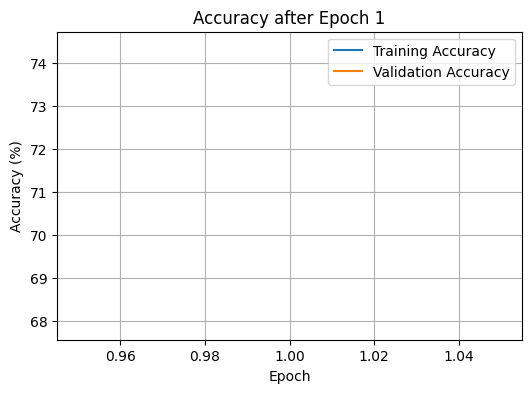

Epoch 2/20 | Train Acc: 74.56% | Val Acc: 69.12%


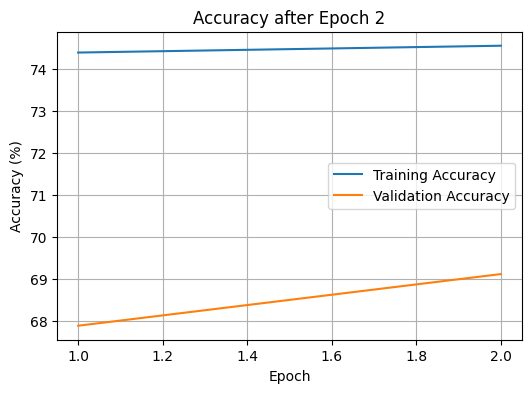

Epoch 3/20 | Train Acc: 75.64% | Val Acc: 73.76%


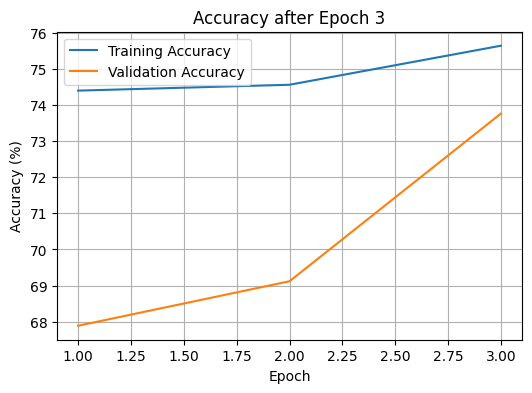

Epoch 4/20 | Train Acc: 75.83% | Val Acc: 72.16%


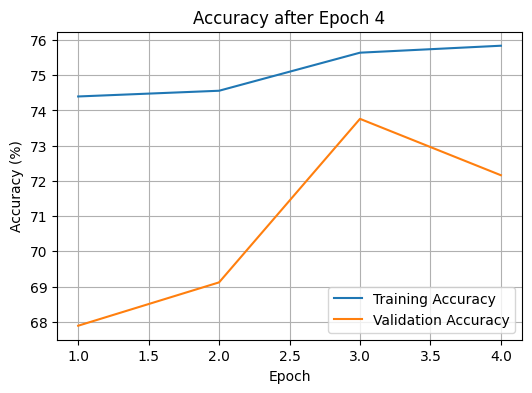

Epoch 5/20 | Train Acc: 76.31% | Val Acc: 74.26%


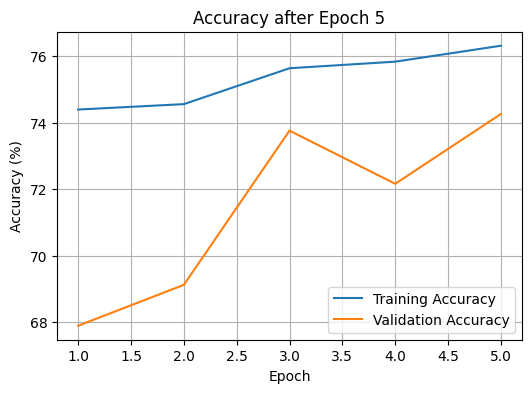

Epoch 6/20 | Train Acc: 76.95% | Val Acc: 73.82%


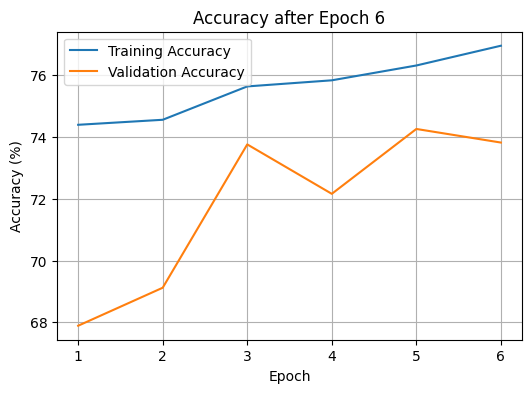

Epoch 7/20 | Train Acc: 77.22% | Val Acc: 74.32%


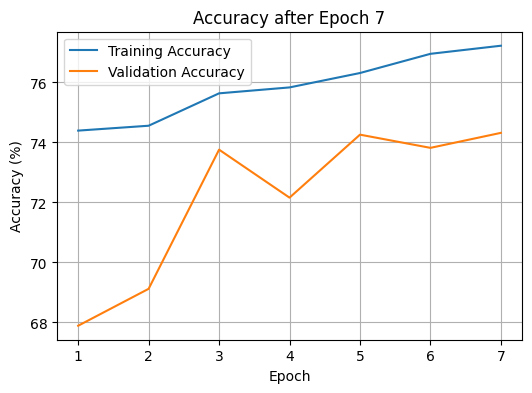

Epoch 8/20 | Train Acc: 77.63% | Val Acc: 75.68%


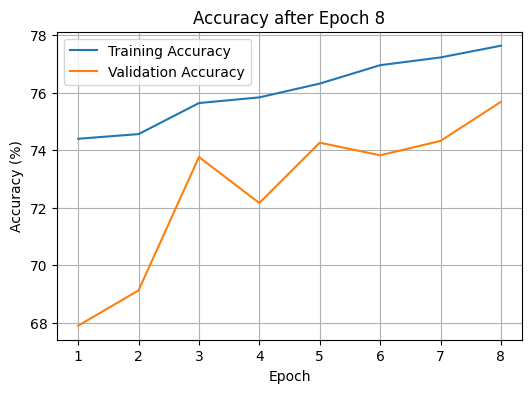

Epoch 9/20 | Train Acc: 78.05% | Val Acc: 72.06%


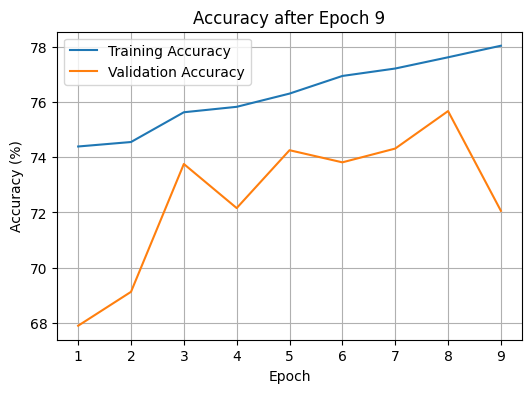

Epoch 10/20 | Train Acc: 78.15% | Val Acc: 74.52%


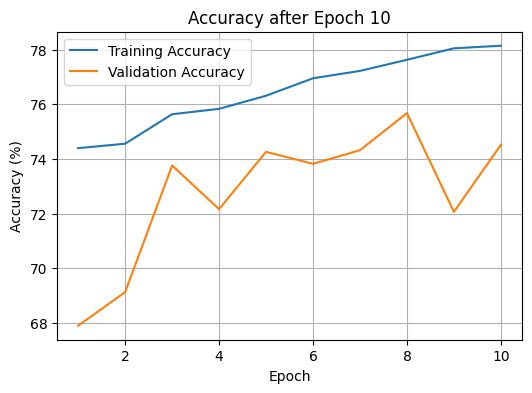

Epoch 11/20 | Train Acc: 78.56% | Val Acc: 71.92%


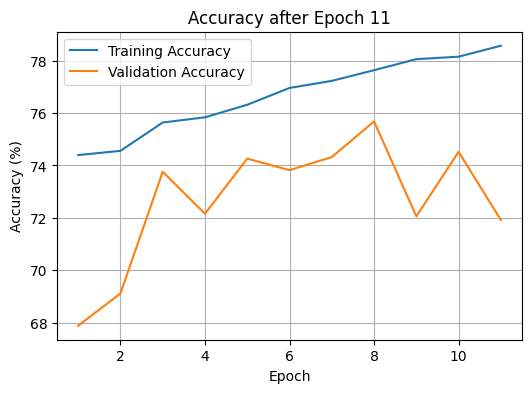

Epoch 12/20 | Train Acc: 78.72% | Val Acc: 77.62%


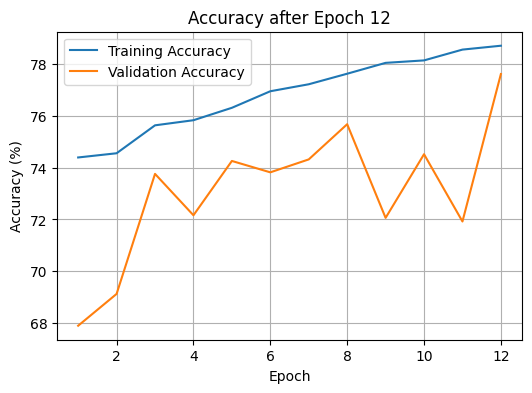

Epoch 13/20 | Train Acc: 78.87% | Val Acc: 74.21%


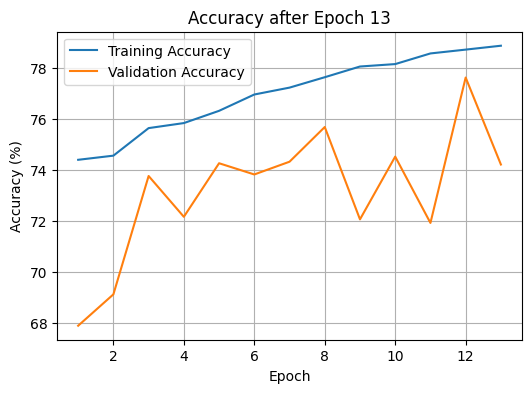

Epoch 14/20 | Train Acc: 79.27% | Val Acc: 77.52%


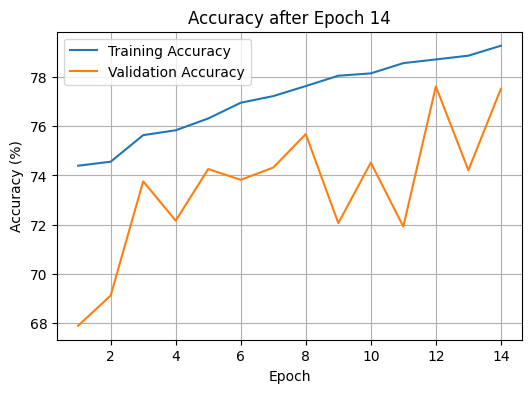

Epoch 15/20 | Train Acc: 79.79% | Val Acc: 77.42%


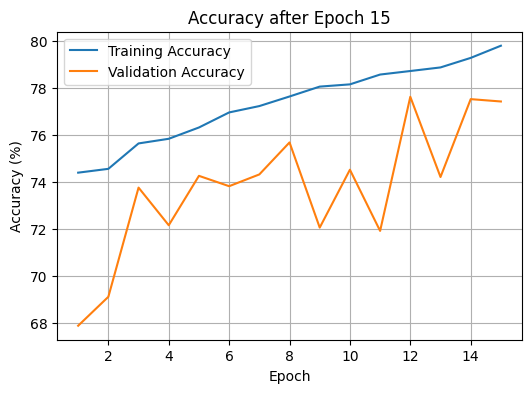

Epoch 16/20 | Train Acc: 80.00% | Val Acc: 75.62%


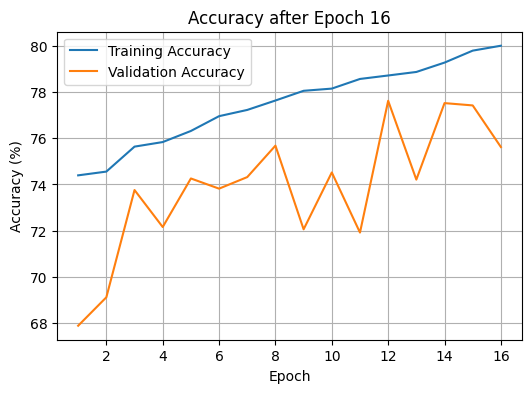

Epoch 17/20 | Train Acc: 79.98% | Val Acc: 77.39%


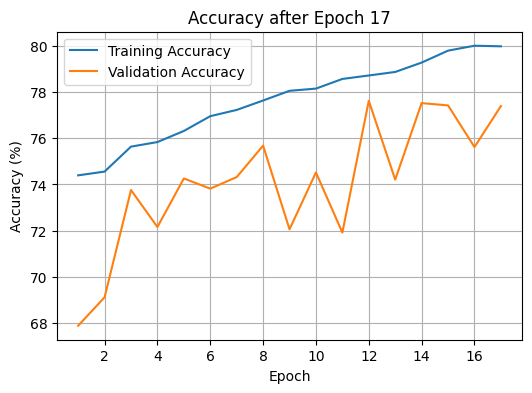

Epoch 18/20 | Train Acc: 80.16% | Val Acc: 76.52%


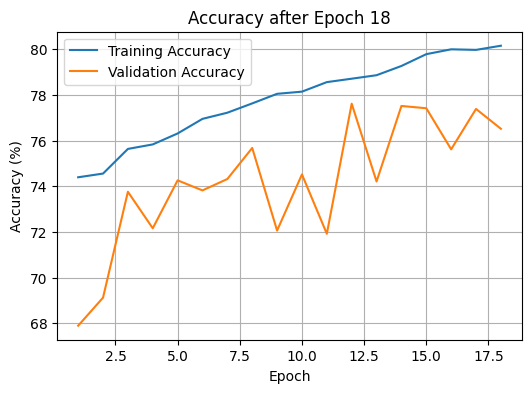

Epoch 19/20 | Train Acc: 80.29% | Val Acc: 74.95%


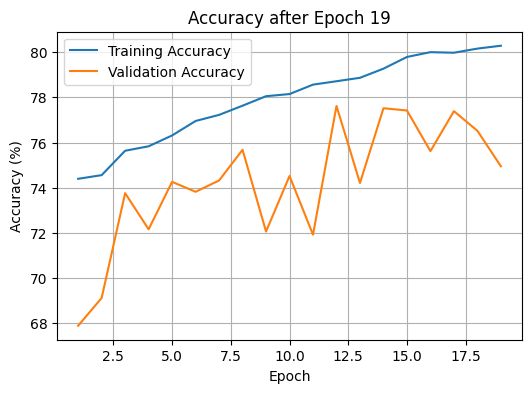

Epoch 20/20 | Train Acc: 80.64% | Val Acc: 77.24%


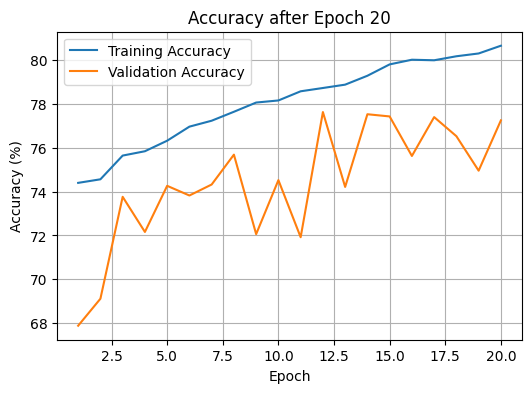

In [ ]:
import matplotlib.pyplot as plt

train_acc_list = []
val_acc_list = []

for epoch in range(epochs):
    model2.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model2(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_acc = 100 * correct_train / total_train
    train_acc_list.append(train_acc)

    # ---- Validation / Test Accuracy ----
    model2.eval()
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:   # or test_loader
            images, labels = images.to(device), labels.to(device)
            outputs = model2(images)

            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_acc = 100 * correct_val / total_val
    val_acc_list.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

    plt.figure(figsize=(6,4))
    plt.plot(range(1, epoch+2), train_acc_list, label="Training Accuracy")
    plt.plot(range(1, epoch+2), val_acc_list, label="Validation Accuracy")

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title(f"Accuracy after Epoch {epoch+1}")
    plt.legend()
    plt.grid(True)
    plt.show()


#Test Loop

In [ ]:
model2.eval()
test_loss = 0
correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model2(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = 100 * correct / total
test_loss /= len(test_loader)

print(f"Test Accuracy: {test_acc:.2f}%")
print(f"Test Cross-Entropy Loss: {test_loss:.4f}")


Test Accuracy: 76.75%
Test Cross-Entropy Loss: 0.6705


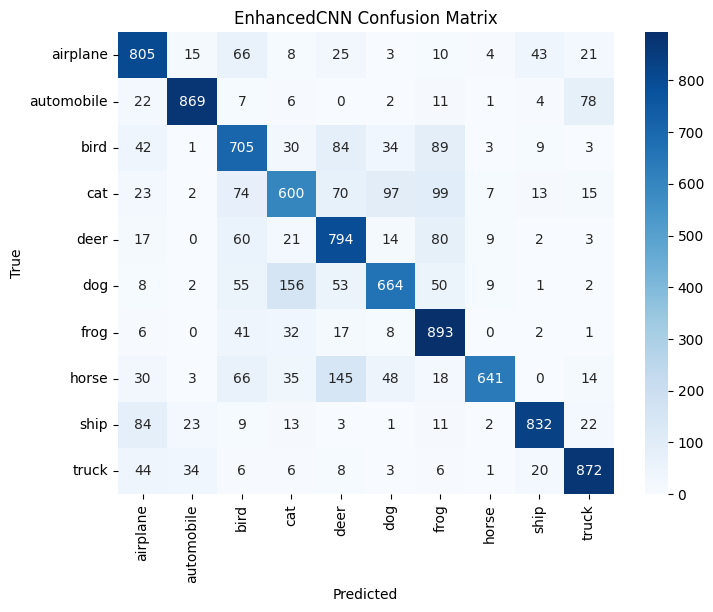

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes,
            yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("EnhancedCNN Confusion Matrix")
plt.show()


In [ ]:
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

i, j = np.unravel_index(np.argmax(cm_no_diag), cm_no_diag.shape)
print(f"Most confused classes: {classes[i]} → {classes[j]}")

Most confused classes: dog → cat


In [ ]:
from torchsummary import summary
summary(model2, input_size=(3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
       BatchNorm2d-2           [-1, 32, 32, 32]              64
         MaxPool2d-3           [-1, 32, 16, 16]               0
            Conv2d-4           [-1, 64, 16, 16]          18,496
       BatchNorm2d-5           [-1, 64, 16, 16]             128
         MaxPool2d-6             [-1, 64, 8, 8]               0
            Conv2d-7            [-1, 128, 8, 8]          73,856
       BatchNorm2d-8            [-1, 128, 8, 8]             256
         MaxPool2d-9            [-1, 128, 4, 4]               0
           Conv2d-10             [-1, 10, 4, 4]           1,290
AdaptiveAvgPool2d-11             [-1, 10, 1, 1]               0
Total params: 94,986
Trainable params: 94,986
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/ba

The Enhanced CNN is architecturally simpler. altough the accuracy has dropped, it has a fewer parameters and is easier to scale.